In [2]:
#Importar librerias necesarias para el análisis de datos, visualización y modelado
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [3]:
#Cargar el dataset del csv que tenemos
df = pd.read_csv("student_lifestyle_performance_dataset.csv")

In [4]:
#Imprime informacion importante para entender el dataset
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    1000 non-null   int64  
 1   Branch                 1000 non-null   str    
 2   Study_Hours_per_Day    1000 non-null   float64
 3   Sleep_Hours            1000 non-null   float64
 4   Screen_Time_Hours      1000 non-null   float64
 5   Gym_Hours_per_Week     1000 non-null   float64
 6   Diet_Type              1000 non-null   str    
 7   Attendance_Percentage  1000 non-null   float64
 8   Stress_Level_1_to_10   1000 non-null   float64
 9   Residence              1000 non-null   str    
 10  Internal_Marks         1000 non-null   float64
 11  CGPA                   1000 non-null   float64
dtypes: float64(8), int64(1), str(3)
memory usage: 93.9 KB


In [5]:
#Muestra las 5 primeras filas del dataset
df.head(8)

,Age,Branch,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Week,Diet_Type,Attendance_Percentage,Stress_Level_1_to_10,Residence,Internal_Marks,CGPA
0,23,ECE,4.14,6.84,9.23,2.67,Non-Veg,81.24,4.93,Hosteller,65.86,7.52
1,20,Civil,5.97,5.52,3.09,15.61,Veg,90.55,6.96,Day Scholar,62.52,7.21
2,24,Electrical,3.19,3.39,5.02,2.52,Veg,69.40,7.38,Hosteller,40.11,4.84
3,21,CSE,4.77,6.44,9.21,0.00,Non-Veg,80.79,5.84,Day Scholar,61.25,6.74
4,23,Civil,5.42,6.54,4.76,9.93,Veg,82.63,6.67,Day Scholar,64.54,7.77
5,19,ECE,3.01,7.25,5.07,13.89,Non-Veg,80.43,3.28,Hosteller,64.40,7.26
6,23,ECE,2.77,6.24,1.66,8.00,Non-Veg,76.35,3.30,Day Scholar,57.73,6.87
7,24,CSE,3.77,4.71,3.94,9.44,Veg,76.02,4.66,Hosteller,60.32,7.04


In [6]:
#Muestra estadisticas como la desviacion estandar, media, moda o el minimo y maximo
df.describe()

,Age,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Week,Attendance_Percentage,Stress_Level_1_to_10,Internal_Marks,CGPA
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.898000,4.037970,6.525030,4.95191,7.311910,80.084340,4.582850,65.922380,7.319300
std,2.603916,1.434691,1.205664,1.97294,4.949333,8.578242,2.024595,10.123247,0.953812
min,17.000000,0.500000,3.000000,1.00000,0.000000,54.660000,1.000000,35.000000,4.000000
25%,19.000000,3.020000,5.710000,3.49000,3.445000,74.307500,3.095000,59.330000,6.690000
50%,21.000000,4.090000,6.515000,4.95500,6.975000,80.210000,4.540000,65.600000,7.300000
75%,23.000000,5.030000,7.380000,6.37250,10.780000,86.165000,5.962500,72.547500,7.990000
max,25.000000,8.050000,10.000000,10.84000,21.000000,100.000000,10.000000,93.930000,10.000000


In [7]:
#Vemos si hay datos duplicados
df.duplicated().sum()

np.int64(0)

In [8]:
#Vemos si hay datos nulos
df.isnull().sum()

Age                      0
Branch                   0
Study_Hours_per_Day      0
Sleep_Hours              0
Screen_Time_Hours        0
Gym_Hours_per_Week       0
Diet_Type                0
Attendance_Percentage    0
Stress_Level_1_to_10     0
Residence                0
Internal_Marks           0
CGPA                     0
dtype: int64

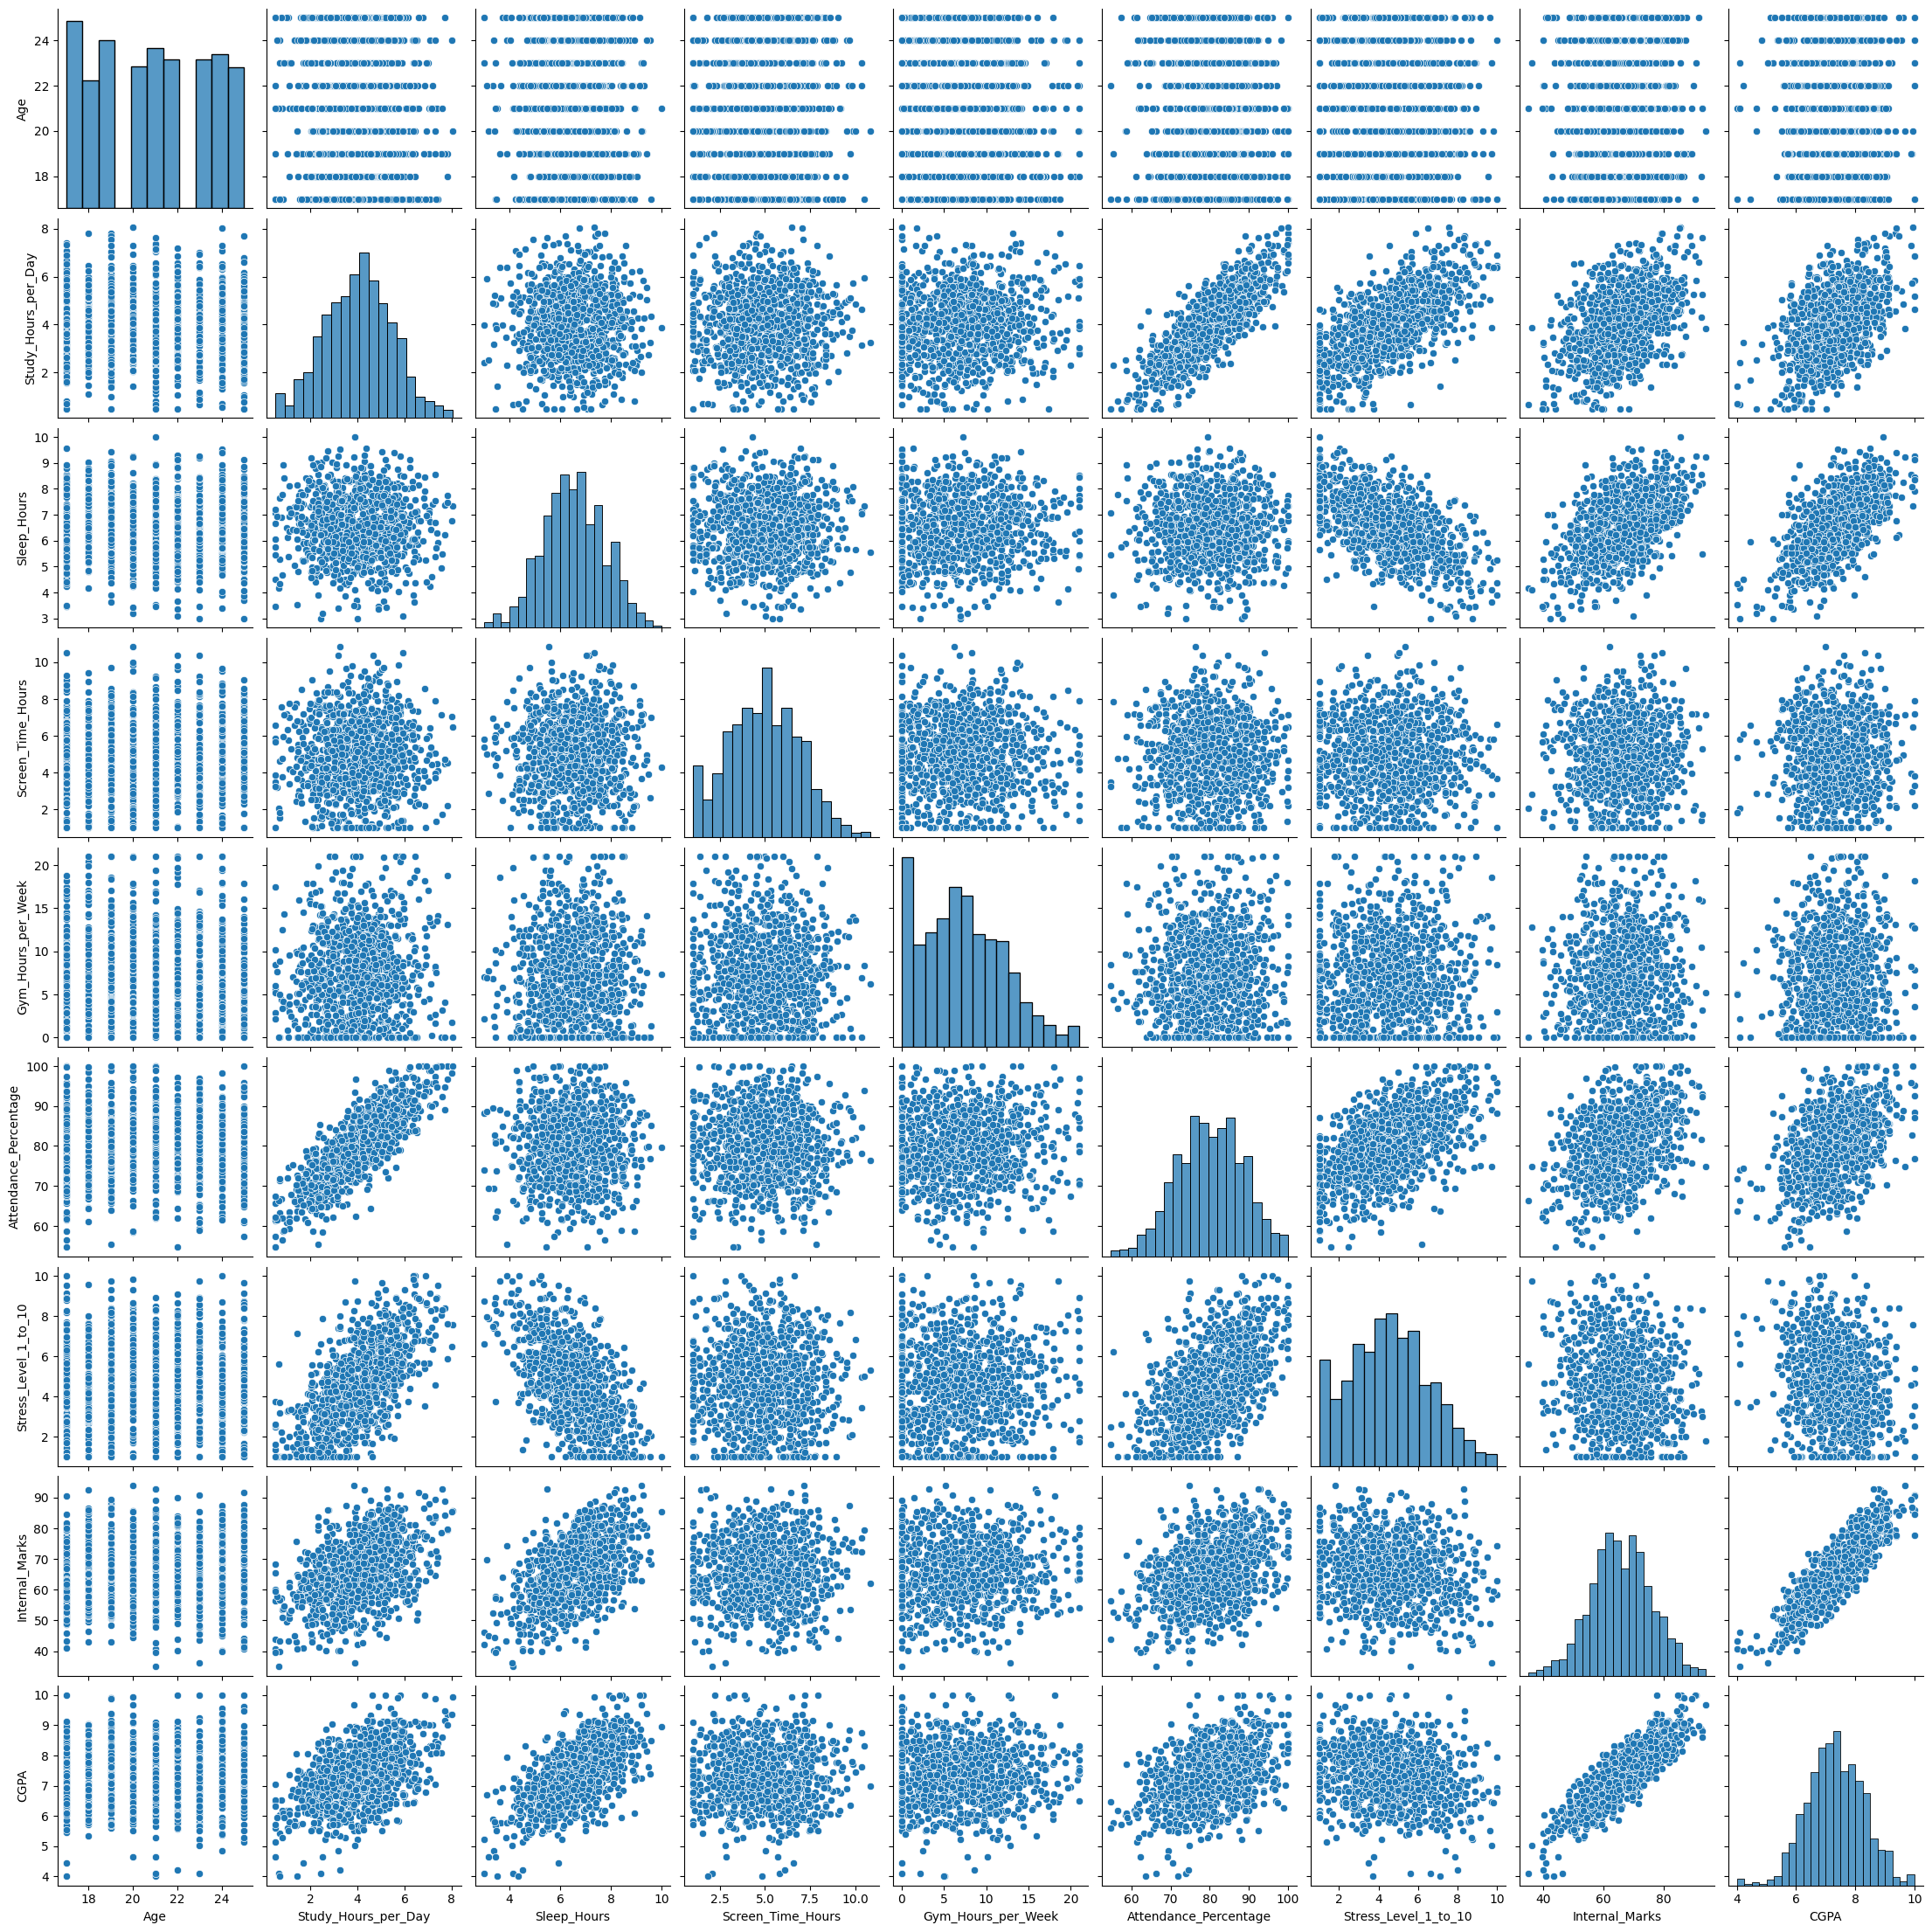

In [9]:
#Visualizamos un grafico para ver la relacion entre las variables
sns.pairplot(df)
plt.show()

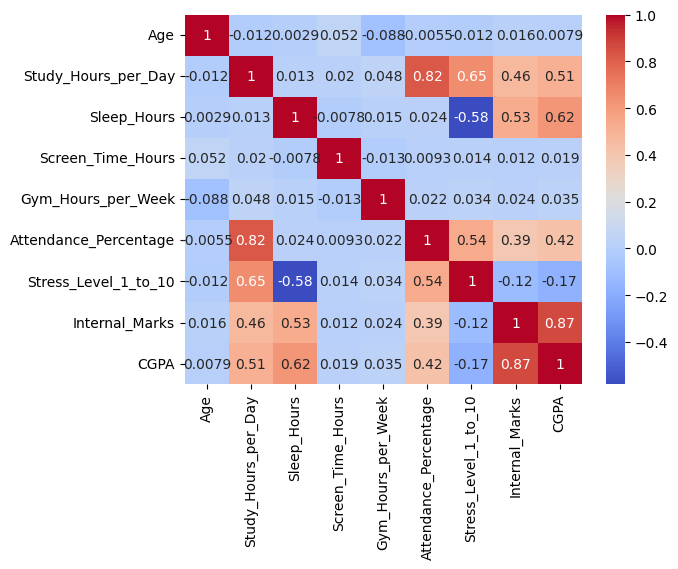

In [10]:
#Visualizamos un mapa de calor para ver la correlacion entre las variables
df_list = ["Age","Study_Hours_per_Day","Sleep_Hours","Screen_Time_Hours","Gym_Hours_per_Week","Attendance_Percentage","Stress_Level_1_to_10","Internal_Marks","CGPA"]
sns.heatmap(df[df_list].corr(), annot=True, cmap="coolwarm")
plt.show()

In [11]:
#Vemos las variables categoricas
print(df["Branch"].value_counts())
print(df["Diet_Type"].value_counts())
print(df["Residence"].value_counts())

Branch
Civil         177
IT            176
CSE           165
ECE           161
Mechanical    161
Electrical    160
Name: count, dtype: int64
Diet_Type
Veg        593
Non-Veg    407
Name: count, dtype: int64
Residence
Hosteller      503
Day Scholar    497
Name: count, dtype: int64


In [12]:
#Usamos OneHotEncoder para convertir las variables categoricas en variables numericas
#Y despues procesarlas para ver si son utiles
categorical_cols = ["Branch", "Diet_Type", "Residence"]
numerical_cols = [col for col in df.columns if col not in categorical_cols]
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_data = encoder.fit_transform(df[categorical_cols])
column_transformer = ColumnTransformer(transformers=[('cat', encoder, categorical_cols)],remainder='passthrough')
X_encoded = column_transformer.fit_transform(df)
encoded_col_names = column_transformer.named_transformers_['cat'].get_feature_names_out(categorical_cols)
final_columns = list(encoded_col_names) + numerical_cols
df_encoded = pd.DataFrame(X_encoded, columns=final_columns)
print(df_encoded.head())


   Branch_Civil  Branch_ECE  Branch_Electrical  Branch_IT  Branch_Mechanical  \
0           0.0         1.0                0.0        0.0                0.0   
1           1.0         0.0                0.0        0.0                0.0   
2           0.0         0.0                1.0        0.0                0.0   
3           0.0         0.0                0.0        0.0                0.0   
4           1.0         0.0                0.0        0.0                0.0   

   Diet_Type_Veg  Residence_Hosteller   Age  Study_Hours_per_Day  Sleep_Hours  \
0            0.0                  1.0  23.0                 4.14         6.84   
1            1.0                  0.0  20.0                 5.97         5.52   
2            1.0                  1.0  24.0                 3.19         3.39   
3            0.0                  0.0  21.0                 4.77         6.44   
4            1.0                  0.0  23.0                 5.42         6.54   

   Screen_Time_Hours  Gym_Hours_

In [13]:
#Verificamos si nuestros datos siguen bien estructurados despues de la codificacion
df_encoded.describe()

,Branch_Civil,Branch_ECE,Branch_Electrical,Branch_IT,Branch_Mechanical,Diet_Type_Veg,Residence_Hosteller,Age,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Week,Attendance_Percentage,Stress_Level_1_to_10,Internal_Marks,CGPA
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.17700,0.161000,0.160000,0.176000,0.161000,0.593000,0.503000,20.898000,4.037970,6.525030,4.95191,7.311910,80.084340,4.582850,65.922380,7.319300
std,0.38186,0.367715,0.366789,0.381011,0.367715,0.491521,0.500241,2.603916,1.434691,1.205664,1.97294,4.949333,8.578242,2.024595,10.123247,0.953812
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.500000,3.000000,1.00000,0.000000,54.660000,1.000000,35.000000,4.000000
25%,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19.000000,3.020000,5.710000,3.49000,3.445000,74.307500,3.095000,59.330000,6.690000
50%,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,21.000000,4.090000,6.515000,4.95500,6.975000,80.210000,4.540000,65.600000,7.300000
75%,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,23.000000,5.030000,7.380000,6.37250,10.780000,86.165000,5.962500,72.547500,7.990000
max,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,25.000000,8.050000,10.000000,10.84000,21.000000,100.000000,10.000000,93.930000,10.000000


<Axes: >

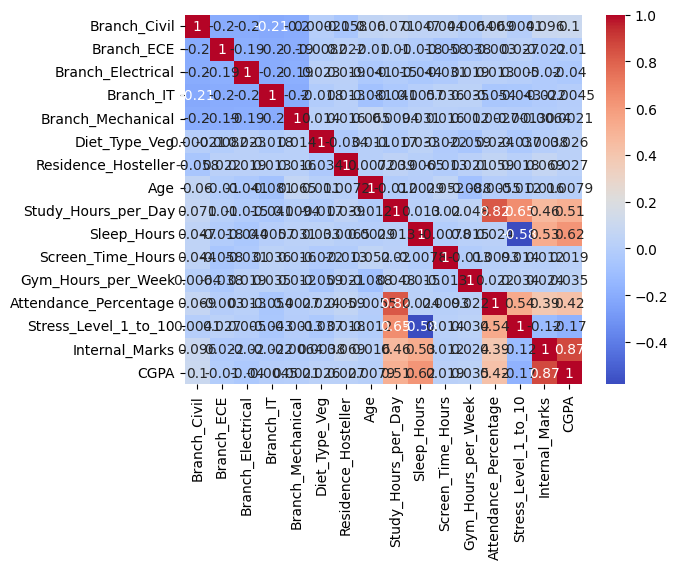

In [14]:
#Hacemos un grafico de calor para ver si realmente tienen alguna rlacion importante con la variable objetivo
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm")

In [15]:
#Seleccionamos las variables que creemos que pueden tener una relacion importante con la variable objetivo y las separamos en X e y
var_cols = ["Branch_Civil", "Branch_ECE", "Branch_Electrical", "Branch_IT", "Branch_Mechanical", "Diet_Type_Veg", "Residence_Hosteller", "Age", "Study_Hours_per_Day", "Sleep_Hours", "Screen_Time_Hours", "Gym_Hours_per_Week", "Attendance_Percentage", "Stress_Level_1_to_10","CGPA"]
X = df_encoded[var_cols]
y = df_encoded["Internal_Marks"]

In [16]:
#Dividimos el dataset en un conjunto de entrenamiento y otro de prueba, entrenamos el modelo de regresion lineal y lo ajustamos a los datos de entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', ["Age", "Study_Hours_per_Day", "Sleep_Hours", "Screen_Time_Hours", "Gym_Hours_per_Week", "Attendance_Percentage", "Stress_Level_1_to_10","CGPA"]),
    ('cat', OneHotEncoder(drop='first'), ["Branch_Civil", "Branch_ECE", "Branch_Electrical", "Branch_IT", "Branch_Mechanical", "Diet_Type_Veg", "Residence_Hosteller"])
])
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
print('ß0: ', round(model.intercept_,3))
for i in range(0, len(model.coef_)):
    print('ß'+str(i+1)+': ', round(model.coef_[i],3), 'asociado a variable', model.feature_names_in_[i])

ß0:  -3.272
ß1:  -0.094 asociado a variable Branch_Civil
ß2:  -0.491 asociado a variable Branch_ECE
ß3:  -0.067 asociado a variable Branch_Electrical
ß4:  -0.398 asociado a variable Branch_IT
ß5:  -0.468 asociado a variable Branch_Mechanical
ß6:  0.015 asociado a variable Diet_Type_Veg
ß7:  0.964 asociado a variable Residence_Hosteller
ß8:  0.019 asociado a variable Age
ß9:  0.191 asociado a variable Study_Hours_per_Day
ß10:  0.022 asociado a variable Sleep_Hours
ß11:  0.007 asociado a variable Screen_Time_Hours
ß12:  -0.017 asociado a variable Gym_Hours_per_Week
ß13:  0.036 asociado a variable Attendance_Percentage
ß14:  -0.008 asociado a variable Stress_Level_1_to_10
ß15:  8.863 asociado a variable CGPA


In [18]:
list(zip(var_cols,model.coef_))

[('Branch_Civil', np.float64(-0.09418231675671777)),
 ('Branch_ECE', np.float64(-0.49062497324192944)),
 ('Branch_Electrical', np.float64(-0.06673046569520877)),
 ('Branch_IT', np.float64(-0.3975381712419396)),
 ('Branch_Mechanical', np.float64(-0.4679817879124466)),
 ('Diet_Type_Veg', np.float64(0.014520634287585342)),
 ('Residence_Hosteller', np.float64(0.9644903272641994)),
 ('Age', np.float64(0.018673680860248953)),
 ('Study_Hours_per_Day', np.float64(0.19097014756308103)),
 ('Sleep_Hours', np.float64(0.021538135655932406)),
 ('Screen_Time_Hours', np.float64(0.007420315962447521)),
 ('Gym_Hours_per_Week', np.float64(-0.01666572041570666)),
 ('Attendance_Percentage', np.float64(0.03615779692220533)),
 ('Stress_Level_1_to_10', np.float64(-0.008111409404836019)),
 ('CGPA', np.float64(8.863410897804927))]

In [19]:
model.score(X_test, y_test)
#model.score(X_train, y_train)

0.7709316947055841

In [20]:
df_encoded['prediction'] = model.predict(X)

df_encoded.sample(15)

,Branch_Civil,Branch_ECE,Branch_Electrical,Branch_IT,Branch_Mechanical,Diet_Type_Veg,Residence_Hosteller,Age,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Week,Attendance_Percentage,Stress_Level_1_to_10,Internal_Marks,CGPA,prediction
797,0.0,1.0,0.0,0.0,0.0,0.0,0.0,17.0,1.84,6.23,5.34,0.00,77.30,3.56,56.63,6.31,55.774578
173,0.0,1.0,0.0,0.0,0.0,1.0,1.0,24.0,2.26,7.64,3.14,7.67,63.02,1.25,68.29,7.38,65.836984
897,1.0,0.0,0.0,0.0,0.0,0.0,0.0,21.0,5.13,7.80,2.49,11.14,83.90,3.07,67.20,8.07,72.543237
90,1.0,0.0,0.0,0.0,0.0,1.0,0.0,17.0,3.65,8.28,3.41,7.03,75.23,1.00,79.03,8.95,79.789192
79,1.0,0.0,0.0,0.0,0.0,0.0,0.0,24.0,2.22,6.66,6.57,6.04,79.48,1.41,56.04,7.09,63.301756
844,0.0,0.0,0.0,1.0,0.0,0.0,1.0,19.0,2.32,7.15,2.53,5.57,66.13,2.88,58.74,6.33,56.646205
21,0.0,0.0,0.0,1.0,0.0,0.0,1.0,22.0,4.56,6.92,4.46,3.38,80.94,4.25,81.55,8.94,80.833751
641,0.0,0.0,0.0,0.0,0.0,0.0,1.0,21.0,5.29,7.70,6.03,4.91,85.98,2.62,86.10,8.92,81.373164
725,0.0,0.0,0.0,0.0,1.0,1.0,1.0,24.0,3.26,9.54,2.64,0.00,76.77,1.00,72.44,7.40,66.892101
337,0.0,0.0,0.0,0.0,0.0,0.0,1.0,20.0,5.17,4.36,4.25,1.37,81.89,9.29,64.59,6.62,60.717591


In [21]:
### metricas
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print('mse: ', round(mse,2), 'Internal_Marks^2')
print('rmse: ', round(np.sqrt(mse),2), 'Internal_Marks')
r2 = r2_score(y_test, y_pred)
print('r2: ', round(r2,2))
mae = mean_absolute_error(y_test, y_pred)
print('mae: ', round(mae,2), 'Internal_Marks')

mse:  26.88 Internal_Marks^2
rmse:  5.18 Internal_Marks
r2:  0.77
mae:  4.18 Internal_Marks


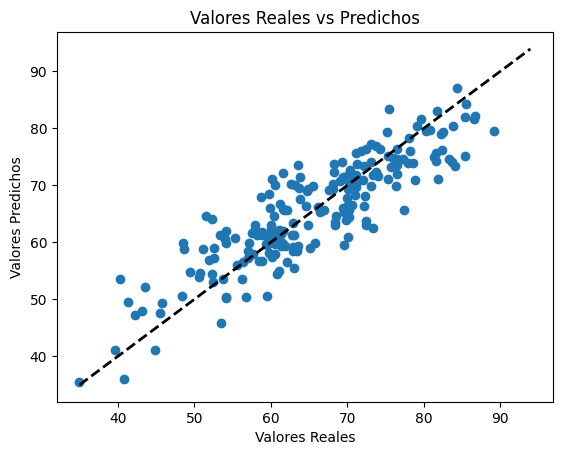

In [22]:
#Graficamos los valores reales con los predichos
plt.scatter(y_test, y_pred)
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('Valores Reales vs Predichos')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.show()

In [23]:
import joblib
from sklearn.pipeline import Pipeline

# Asumiendo que 'preprocessor' es tu ColumnTransformer y 'model' es tu LinearRegression
# Creamos un pipeline que une ambos pasos
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), # Tu ColumnTransformer existente
    ('regressor', model)            # Tu modelo LinearRegression existente
])

# Entrenamos el pipeline completo (si no lo habías hecho así)
full_pipeline.fit(X_train, y_train)

# Guardamos el pipeline en un archivo
joblib.dump(full_pipeline, 'model_pipeline.pkl')
print("Modelo guardado exitosamente como model_pipeline.pkl")

Modelo guardado exitosamente como model_pipeline.pkl


In [24]:
import joblib
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

# 1. Definimos cuáles son las características de entrada (X) y la salida (y)
# (Si usaste CGPA como entrada, déjala. Si no, agrégala al drop)
X = df.drop(columns=["Internal_Marks"]) 
y = df["Internal_Marks"]

# 2. Le decimos al código cuáles son las columnas de texto
categorical_features = ["Branch", "Diet_Type", "Residence"]

# 3. Creamos el "Traductor" (OneHotEncoder)
# handle_unknown="ignore" es magia pura: evita errores en la API si le llega un dato raro
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough" # Las columnas numéricas (Age, Sleep_Hours, etc.) pasan igual
)

# 4. CREAMOS EL PIPELINE (Traductor + Modelo unidos)
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# 5. Entrenamos EL PIPELINE con los datos crudos (sin pd.get_dummies)
pipeline.fit(X, y)

# 6. Sobrescribimos el archivo guardando el Pipeline completo
joblib.dump(pipeline, "model_pipeline.pkl")
print("¡Pipeline exportado correctamente!")

¡Pipeline exportado correctamente!
